In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score

print("All set.")

All set.


In [68]:
data = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(data)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [69]:
df.shape

(7043, 21)

In [70]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [71]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [72]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [73]:
df['MonthlyCharges'].describe()
df['TotalCharges'].describe()

count     7043
unique    6531
top       20.2
freq        11
Name: TotalCharges, dtype: object

In [74]:
df['TotalCharges'].unique()[:20]

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',  '587.45',   '326.8',  '5681.1',  '5036.3',
 '2686.05', '7895.15', '1022.95', '7382.25',  '528.35',  '1862.9']
Length: 20, dtype: str

In [75]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

np.int64(11)

In [76]:
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [77]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [78]:
df['TotalCharges'].isnull().sum()
df['TotalCharges'].dtype

dtype('float64')

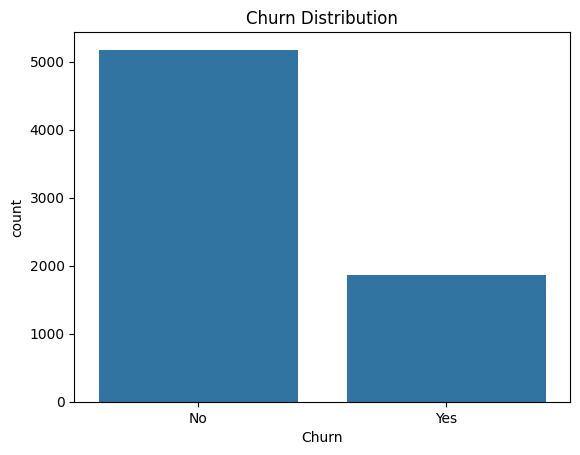

In [79]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

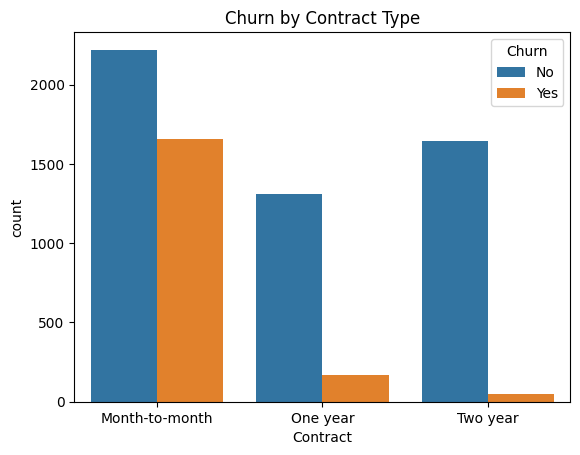

In [80]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

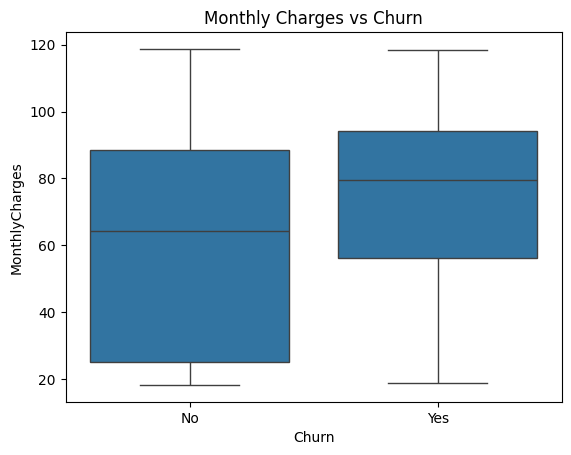

In [81]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

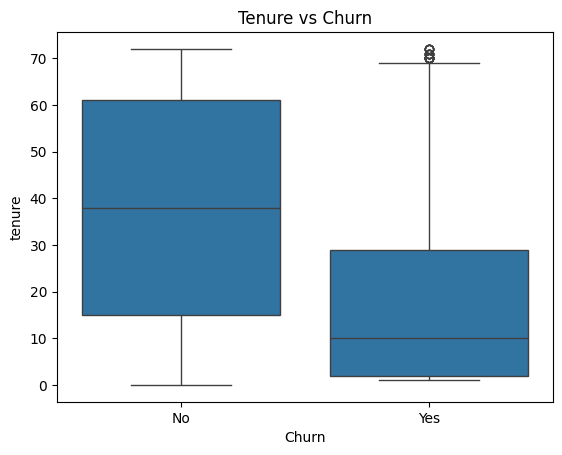

In [82]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

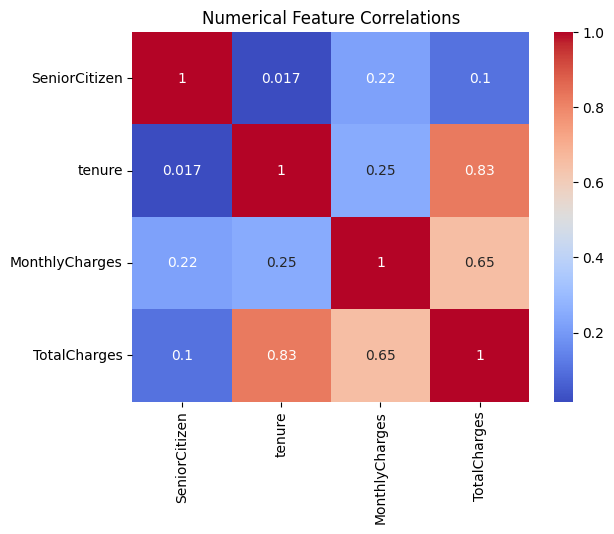

In [83]:

num_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Numerical Feature Correlations')
plt.show()

In [84]:
df.drop('customerID', axis=1, inplace=True)

In [85]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [86]:
cat_cols = df.select_dtypes(include=['str']).columns.tolist()
print("Categorical columns:", cat_cols)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [87]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [88]:
df.shape

(7043, 31)

In [89]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


Modelling Phase

In [90]:
# For Logistic Regression (predict churn)
X_clf = df.drop('Churn', axis=1)
y_clf = df['Churn']

# For Linear Regression — both targets
X_reg = df.drop(['MonthlyCharges', 'TotalCharges'], axis=1)
y_reg_monthly = df['MonthlyCharges']
y_reg_total = df['TotalCharges']

In [91]:
# Logistic
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# Linear — Monthly
X_train_rm, X_test_rm, y_train_rm, y_test_rm = train_test_split(X_reg, y_reg_monthly, test_size=0.2, random_state=42)

# Linear — Total
X_train_rt, X_test_rt, y_train_rt, y_test_rt = train_test_split(X_reg, y_reg_total, test_size=0.2, random_state=42)

In [92]:
# Logistic Scaling
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

In [93]:
# Linear (Monthly) Scaling
scaler_rm = StandardScaler()
X_train_rm_scaled = scaler_rm.fit_transform(X_train_rm)
X_test_rm_scaled = scaler_rm.transform(X_test_rm)

In [94]:
# Linear (Total) Scaling
scaler_rt = StandardScaler()
X_train_rt_scaled = scaler_rt.fit_transform(X_train_rt)
X_test_rt_scaled = scaler_rt.transform(X_test_rt)


In [95]:
# Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train_c_scaled, y_train_c)

# Linear Regression — Monthly
lin_monthly = LinearRegression()
lin_monthly.fit(X_train_rm_scaled, y_train_rm)

# Linear Regression — Total
lin_total = LinearRegression()
lin_total.fit(X_train_rt_scaled, y_train_rt)

print("All models trained.")

All models trained.


Evaluation

In [96]:
y_pred_c = log_model.predict(X_test_c_scaled)
y_proba_c = log_model.predict_proba(X_test_c_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_c, y_pred_c))
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_c))

Accuracy: 0.8204400283889283

Confusion Matrix:
 [[934 102]
 [151 222]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



In [97]:
y_pred_rm = lin_monthly.predict(X_test_rm_scaled)

print("Monthly Charges Model")
print("R²:", r2_score(y_test_rm, y_pred_rm))
print("RMSE:", np.sqrt(mean_squared_error(y_test_rm, y_pred_rm)))

Monthly Charges Model
R²: 0.9987783007645167
RMSE: 1.0517107419969802


In [98]:
y_pred_rt = lin_total.predict(X_test_rt_scaled)

print("Total Charges Model")
print("R²:", r2_score(y_test_rt, y_pred_rt))
print("RMSE:", np.sqrt(mean_squared_error(y_test_rt, y_pred_rt)))

Total Charges Model
R²: 0.9052864881571447
RMSE: 701.9534551748766


In [101]:
coefs = pd.DataFrame({
    'feature': X_clf.columns,
    'coefficient': log_model.coef_[0]
})
coefs['abs_coef'] = abs(coefs['coefficient'])
coefs = coefs.sort_values('abs_coef', ascending=False)
print(coefs.head(10))

                        feature  coefficient  abs_coef
1                        tenure    -1.347355  1.347355
3                  TotalCharges     0.649427  0.649427
2                MonthlyCharges    -0.628014  0.628014
10  InternetService_Fiber optic     0.619853  0.619853
25            Contract_Two year    -0.613702  0.613702
24            Contract_One year    -0.268336  0.268336
23          StreamingMovies_Yes     0.228714  0.228714
21              StreamingTV_Yes     0.179380  0.179380
9             MultipleLines_Yes     0.168199  0.168199
26         PaperlessBilling_Yes     0.163829  0.163829
